We explore the train.parquet datasets.

In [17]:
import os 
import duckdb

dir_data = "data/enveda-CASMI26-molecule-id-mass-spectra"
train_path = os.path.join(dir_data, 'train.parquet')

# Connect to the parquet file
conn = duckdb.connect(':memory:')

In [18]:
# Get basic statistics
print(conn.execute(f"""
    SELECT 
        COUNT(*) as total_rows,
        COUNT(DISTINCT normalized_smiles) as unique_molecules,
        COUNT(DISTINCT instrument_type) as num_instruments,
        COUNT(DISTINCT ionization_mode) as num_ionization_modes
    FROM '{train_path}'
""").fetchall())

[(2539608, 277566, 82, 2)]


In [19]:
# Explore columns
print(conn.execute(f"""
    SELECT 
        ionization_mode,
        instrument_type,
        adduct,
        COUNT(*) as count
    FROM '{train_path}'
    GROUP BY ionization_mode, instrument_type, adduct
    ORDER BY count DESC
""").fetchall())

[('positive', 'timsTOF', '[M+H]+', 589076), ('positive', 'Orbitrap', '[M+H]+', 411236), ('positive', 'timsTOF', '[2M+Na]+', 188158), ('negative', 'timsTOF', '[M-H]-', 185023), ('negative', 'Orbitrap', '[M-H]-', 153786), ('positive', 'timsTOF', '[2M+H]+', 89487), ('positive', 'QTOF', '[M+H]+', 64466), ('positive', 'Orbitrap', '[M+Na]+', 64177), ('positive', 'QTOF', '[M+Na]+', 61470), ('positive', 'LC-ESI-QTOF', '[M+H]+', 58367), ('negative', 'Orbitrap', '[M+CH2O2-H]-', 53870), ('negative', 'timsTOF', '[2M-H]-', 52933), ('positive', 'LC-ESI-QFT', '[M+H]+', 35145), ('positive', 'LC-ESI-ITFT', '[M+H]+', 32471), ('negative', 'LC-ESI-QTOF', '[M-H]-', 30231), ('negative', 'timsTOF', '[M+CH2O2-H]-', 24661), ('negative', 'Orbitrap', '[M+Cl]-', 24438), ('positive', 'qTof', '[M+H]+', 21158), ('negative', 'LC-ESI-QFT', '[M-H]-', 18860), ('positive', 'ToF', '[M+H]+', 18834), ('positive', 'ESI-QFT', '[M+H]+', 17970), ('negative', 'ESI-QFT', '[M-H]-', 17471), ('positive', 'timsTOF', '[M+Na]+', 16037)

In [20]:
# Check for nulls
print(conn.execute(f"""
    SELECT 
        SUM(CASE WHEN normalized_smiles IS NULL THEN 1 ELSE 0 END) as null_smiles,
        SUM(CASE WHEN ms2_mzs IS NULL THEN 1 ELSE 0 END) as null_mzs,
        SUM(CASE WHEN num_peaks IS NULL THEN 1 ELSE 0 END) as null_peaks
    FROM '{train_path}'
""").fetchall())

[(0, 0, 0)]


In [21]:
# Look at a sample
sample = conn.execute(f"""
    SELECT * FROM '{train_path}'
    LIMIT 5
""").df()
print(sample)

  ingest_lib                                  normalized_smiles  \
0  drug_plus          O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21   
1  drug_plus         C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1   
2  drug_plus  CC1(C)CCC(C)(C)c2cc(C(O)C(O)=Nc3ccc(C(=O)O)cc3...   
3  drug_plus                CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21   
4  drug_plus  NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4c...   

                      inchikey      inchikey14 molecular_formula  \
0  AAALVYBICLMAMA-UHFFFAOYSA-N  AAALVYBICLMAMA        C20H15N3O2   
1  AAKJLRGGTJKAMG-UHFFFAOYSA-N  AAKJLRGGTJKAMG        C22H23N3O4   
2  AANFHDFOMFRLLR-UHFFFAOYSA-N  AANFHDFOMFRLLR        C23H26FNO4   
3  AAOVKJBEBIDNHE-UHFFFAOYSA-N  AAOVKJBEBIDNHE       C16H13ClN2O   
4  ACFIXJIJDZMPPO-UHFFFAOYSA-N  ACFIXJIJDZMPPO     C21H30N7O17P3   

  ionization_mode instrument_type   adduct adduct_orig  precursor_mz  \
0        positive            None   [M+H]+      [M+H]+      330.1237   
1        positive            None   [M+K]+  

## Test set exploration (polars)

`test.parquet` is 4.8 MB (1,213 spectra, 400 molecules), so everything fits in memory and every cell runs instantly.

In [22]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)

dir_data = "data/enveda-CASMI26-molecule-id-mass-spectra"
test = pl.read_parquet(os.path.join(dir_data, "test.parquet"))
sample_sub = pl.read_csv(os.path.join(dir_data, "sample_submission.csv"))

print(test.shape)
test.head()

(1213, 12)


molecule_id,spectrum_id,ms2_mzs,ms2_normalized_intensities,base_peak_intensity,adduct,ionization_mode,instrument_type,precursor_mz,collision_energy_orig,collision_energy_ev,collision_energy_orig_units
str,str,list[f64],list[f64],f64,str,str,str,f64,str,list[f64],str
"""m_005e53""","""s_4d19d522""","[67.0414, 73.0074, … 377.1517]","[0.00165, 0.000491, … 0.000098]",2.711324e6,"""[M+H]+""","""positive""","""timsTOF""",375.0709,"""20,40,60""","[20.0, 40.0, 60.0]","""eV"""
"""m_005e53""","""s_5b6e28ff""","[67.0414, 73.0074, … 376.0738]","[0.002958, 0.00088, … 0.000181]",1.512428e6,"""[M+H]+""","""positive""","""timsTOF""",375.0709,"""40""",[40.0],"""eV"""
"""m_005e53""","""s_6e514292""","[74.0142, 75.0238, … 273.115]","[0.007141, 0.00972, … 0.000116]",989677.0,"""[M+H]+""","""positive""","""timsTOF""",375.0709,"""60""",[60.0],"""eV"""
"""m_005e53""","""s_855ae19c""","[42.9863, 45.6701, … 375.0851]","[0.00143, 0.00143, … 0.00143]",6295.0,"""[M-H]-""","""negative""","""timsTOF""",373.0562,"""-60""",[60.0],"""eV"""
"""m_006153""","""s_3c74e9fe""","[65.0391, 77.0385, … 344.0806]","[0.000254, 0.000978, … 0.00005]",3.191374e6,"""[M+H]+""","""positive""","""timsTOF""",342.1569,"""20""",[20.0],"""eV"""


In [23]:
# No nulls, one instrument, one energy unit
print(test.null_count().sum_horizontal().item(), "nulls")
print(test.select(pl.all().exclude("ms2_mzs", "ms2_normalized_intensities").n_unique()))

print(test.group_by("ionization_mode", "adduct").len().sort("len", descending=True))
print(test.group_by("collision_energy_orig").len().sort("len", descending=True))

# Submission: one row per test molecule, 25 ';'-separated candidate SMILES
assert set(sample_sub["molecule_id"]) == set(test["molecule_id"])
print(sample_sub["smiles"].str.split(";").list.len().unique().to_list(), "candidates per molecule")

0 nulls
shape: (1, 10)
┌─────────┬─────────┬─────────┬────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ molecul ┆ spectru ┆ base_pe ┆ adduct ┆ ionizat ┆ instrum ┆ precurs ┆ collisi ┆ collisi ┆ collisi │
│ e_id    ┆ m_id    ┆ ak_inte ┆ ---    ┆ ion_mod ┆ ent_typ ┆ or_mz   ┆ on_ener ┆ on_ener ┆ on_ener │
│ ---     ┆ ---     ┆ nsity   ┆ u32    ┆ e       ┆ e       ┆ ---     ┆ gy_orig ┆ gy_ev   ┆ gy_orig │
│ u32     ┆ u32     ┆ ---     ┆        ┆ ---     ┆ ---     ┆ u32     ┆ ---     ┆ ---     ┆ _units  │
│         ┆         ┆ u32     ┆        ┆ u32     ┆ u32     ┆         ┆ u32     ┆ u32     ┆ ---     │
│         ┆         ┆         ┆        ┆         ┆         ┆         ┆         ┆         ┆ u32     │
╞═════════╪═════════╪═════════╪════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╡
│ 400     ┆ 1213    ┆ 1205    ┆ 7      ┆ 2       ┆ 1       ┆ 591     ┆ 8       ┆ 4       ┆ 1       │
└─────────┴─────────┴─────────┴────────┴─────────┴─────────┴────────

### Molecules

In [24]:
# Neutral monoisotopic mass M from each spectrum: precursor_mz = M + adduct shift
ADDUCT_SHIFT = {
    "[M+H]+": 1.007276,
    "[M+Na]+": 22.989218,
    "[M+NH4]+": 18.033823,
    "[M+K]+": 38.963158,
    "[M-H]-": -1.007276,
    "[M+Cl]-": 34.969402,
    "[M+CH2O2-H]-": 44.998201,
}
test = test.with_columns(
    neutral_mass=pl.col("precursor_mz") - pl.col("adduct").replace_strict(ADDUCT_SHIFT),
    n_peaks=pl.col("ms2_mzs").list.len(),
)

# One row per molecule: how it was measured, and its neutral mass
molecules = (
    test
    .group_by("molecule_id")
    .agg(
        n_spectra=pl.len(),
        polarities=pl.col("ionization_mode").unique().sort(),
        adducts=pl.col("adduct").unique().sort(),
        energies=pl.col("collision_energy_orig").sort(),
        neutral_mass=pl.col("neutral_mass").mean(),
        mass_spread_ppm=(pl.col("neutral_mass").max() - pl.col("neutral_mass").min()) / pl.col("neutral_mass").mean() * 1e6,
        total_peaks=pl.col("n_peaks").sum(),
    )
    .sort("molecule_id")
)

print(molecules["n_spectra"].value_counts().sort("n_spectra"))
print(molecules["polarities"].list.join("+").value_counts(sort=True))
# All spectra of a molecule agree on its neutral mass to a few ppm
molecules.select("neutral_mass", "mass_spread_ppm").describe()

shape: (9, 2)
┌───────────┬───────┐
│ n_spectra ┆ count │
│ ---       ┆ ---   │
│ u32       ┆ u32   │
╞═══════════╪═══════╡
│ 1         ┆ 55    │
│ 2         ┆ 97    │
│ 3         ┆ 99    │
│ 4         ┆ 106   │
│ 5         ┆ 24    │
│ 6         ┆ 14    │
│ 7         ┆ 2     │
│ 8         ┆ 2     │
│ 9         ┆ 1     │
└───────────┴───────┘
shape: (3, 2)
┌───────────────────┬───────┐
│ polarities        ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ positive          ┆ 276   │
│ negative+positive ┆ 97    │
│ negative          ┆ 27    │
└───────────────────┴───────┘


statistic,neutral_mass,mass_spread_ppm
str,f64,f64
"""count""",400.0,400.0
"""null_count""",0.0,0.0
"""mean""",326.345253,0.462126
"""std""",36.442015,0.920967
"""min""",246.100712,0.0
"""25%""",299.139499,0.0
"""50%""",328.190524,0.0
"""75%""",346.156424,0.342279
"""max""",439.103724,5.494401


### Peaks

In [25]:
# Long format: one row per peak (~400k rows), easy to aggregate
peaks = (
    test
    .select("molecule_id", "spectrum_id", "ionization_mode", "collision_energy_orig", "precursor_mz",
            mz="ms2_mzs", intensity="ms2_normalized_intensities")
    .explode("mz", "intensity")
    .with_columns(rel_mz=pl.col("mz") / pl.col("precursor_mz"))
)
print(peaks.shape)

# Most peaks are tiny: a long tail of low-intensity signal
print(peaks.select(
    below_1pct=(pl.col("intensity") < 0.01).mean(),
    below_01pct=(pl.col("intensity") < 0.001).mean(),
    above_precursor=(pl.col("rel_mz") > 1.0001).mean(),
))

# Peaks per spectrum by collision energy and polarity
(
    test
    .group_by("ionization_mode", "collision_energy_orig")
    .agg(spectra=pl.len(), median_peaks=pl.col("n_peaks").median(), max_peaks=pl.col("n_peaks").max())
    .sort("ionization_mode", "collision_energy_orig")
)

(400707, 8)
shape: (1, 3)
┌────────────┬─────────────┬─────────────────┐
│ below_1pct ┆ below_01pct ┆ above_precursor │
│ ---        ┆ ---         ┆ ---             │
│ f64        ┆ f64         ┆ f64             │
╞════════════╪═════════════╪═════════════════╡
│ 0.926131   ┆ 0.765465    ┆ 0.032997        │
└────────────┴─────────────┴─────────────────┘


/var/folders/z_/8ffvxcfj1r9cthjb55dvwpb80000gn/T/ipykernel_37238/3444039566.py:6: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("mz", "intensity")


ionization_mode,collision_energy_orig,spectra,median_peaks,max_peaks
str,str,u32,f64,u32
"""negative""","""-20""",30,75.5,461
"""negative""","""-40""",81,62.0,1427
"""negative""","""-60""",74,39.5,946
"""negative""","""-60,-40,-20""",41,136.0,3259
"""positive""","""20""",160,186.0,1205
"""positive""","""20,40,60""",257,477.0,3140
"""positive""","""40""",281,261.0,1269
"""positive""","""60""",289,230.0,2344


### Plots

In [26]:
# Shared plot style: thin marks, recessive axes, one color per polarity
MODE_COLORS = {"positive": "#2a78d6", "negative": "#eb6834"}
INK, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": INK_MUTED,
    "axes.labelcolor": INK_MUTED,
    "axes.titlecolor": INK,
    "axes.titlelocation": "left",
    "axes.titlesize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "legend.frameon": False,
    "font.size": 10,
})


def plot_spectrum(ax, row, title=None):
    """Stem plot of one spectrum, colored by polarity, with the precursor m/z as a dashed line."""
    ax.vlines(row["ms2_mzs"], 0, row["ms2_normalized_intensities"], color=MODE_COLORS[row["ionization_mode"]], linewidth=1)
    ax.axvline(row["precursor_mz"], color=INK_MUTED, linestyle="--", linewidth=1)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="x", visible=False)
    ax.set_title(title or "")

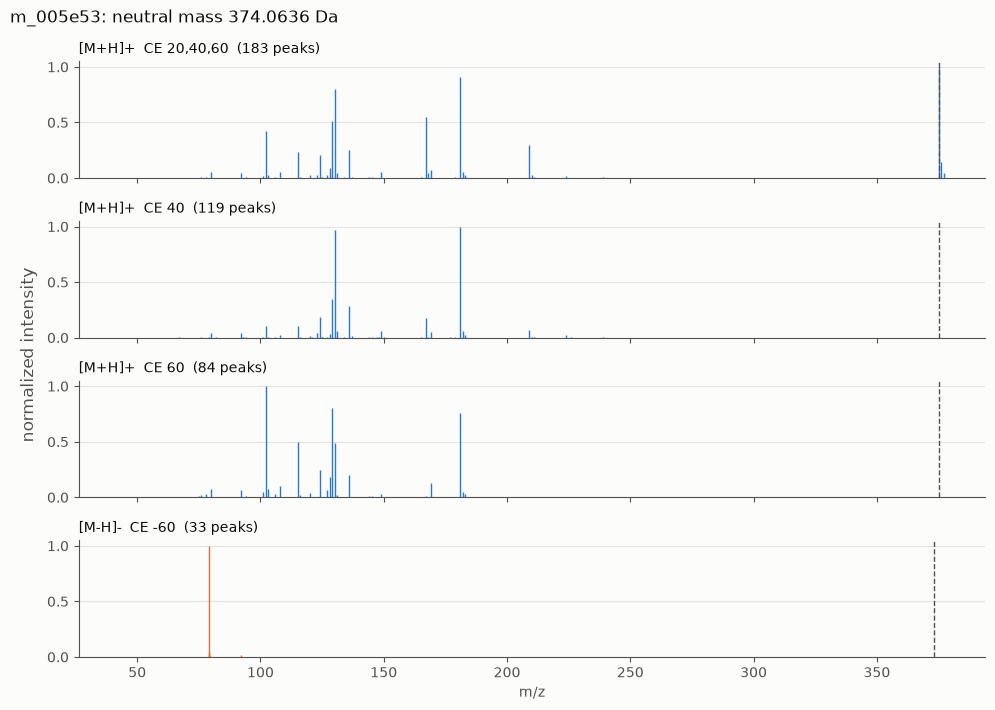

In [27]:
# All spectra of one molecule; change molecule_id to browse others
molecule_id = "m_005e53"
mol_spectra = test.filter(pl.col("molecule_id") == molecule_id).sort("ionization_mode", "collision_energy_orig", descending=[True, False])

fig, axes = plt.subplots(len(mol_spectra), 1, figsize=(10, 1.8 * len(mol_spectra)), sharex=True, squeeze=False)
for ax, row in zip(axes[:, 0], mol_spectra.iter_rows(named=True)):
    plot_spectrum(ax, row, f"{row['adduct']}  CE {row['collision_energy_orig']}  ({row['n_peaks']} peaks)")
axes[-1, 0].set_xlabel("m/z")
fig.supylabel("normalized intensity", color=INK_MUTED)
fig.suptitle(f"{molecule_id}: neutral mass {mol_spectra['neutral_mass'].mean():.4f} Da", x=0.01, ha="left", color=INK)
fig.tight_layout()
plt.show()

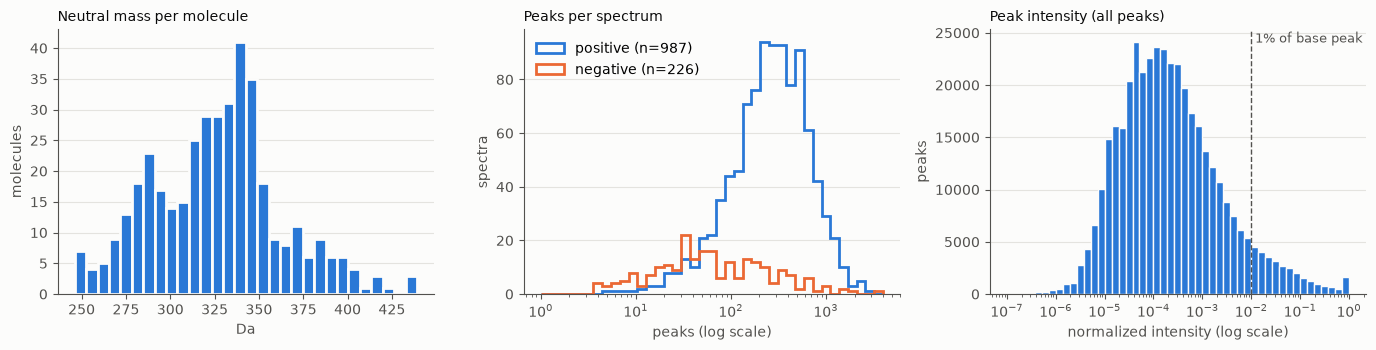

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

# Neutral mass per molecule
axes[0].hist(molecules["neutral_mass"], bins=30, color=MODE_COLORS["positive"], edgecolor="#fcfcfb", linewidth=2)
axes[0].set(title="Neutral mass per molecule", xlabel="Da", ylabel="molecules")

# Peaks per spectrum, by polarity
bins = np.logspace(0, 3.6, 40)
for mode, color in MODE_COLORS.items():
    values = test.filter(pl.col("ionization_mode") == mode)["n_peaks"]
    axes[1].hist(values, bins=bins, histtype="step", linewidth=2, color=color, label=f"{mode} (n={len(values)})")
axes[1].set(title="Peaks per spectrum", xscale="log", xlabel="peaks (log scale)", ylabel="spectra")
axes[1].legend(loc="upper left")

# Intensity of every peak
axes[2].hist(peaks["intensity"], bins=np.logspace(-7, 0, 50), color=MODE_COLORS["positive"], edgecolor="#fcfcfb", linewidth=1)
axes[2].axvline(0.01, color=INK_MUTED, linestyle="--", linewidth=1)
axes[2].annotate("1% of base peak", (0.012, 0.95), xycoords=("data", "axes fraction"), color=INK_MUTED, fontsize=9)
axes[2].set(title="Peak intensity (all peaks)", xscale="log", xlabel="normalized intensity (log scale)", ylabel="peaks")

for ax in axes:
    ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

### Merged-energy spectra

In [29]:
# Are '20,40,60' spectra the single-energy spectra merged? Share of merged intensity on peaks
# (within 0.01 m/z) that also appear in a single-energy spectrum of the same molecule and adduct
def shared_intensity(group: pl.DataFrame) -> float | None:
    is_merged = group["collision_energy_orig"].str.contains(",")
    merged, singles = group.filter(is_merged), group.filter(~is_merged)
    if merged.is_empty() or singles.height < 2:
        return None
    mz = np.asarray(merged["ms2_mzs"][0])
    weights = np.asarray(merged["ms2_normalized_intensities"][0])
    single_mz = np.unique(np.concatenate(singles["ms2_mzs"].to_list()))
    idx = np.clip(np.searchsorted(single_mz, mz), 1, len(single_mz) - 1)
    dist = np.minimum(np.abs(single_mz[idx] - mz), np.abs(single_mz[idx - 1] - mz))
    return float(weights[dist < 0.01].sum() / weights.sum())


shares = [
    s for _, group in test.group_by("molecule_id", "adduct")
    if (s := shared_intensity(group)) is not None
]
pl.Series("shared_intensity", shares).describe()

statistic,value
str,f64
"""count""",204.0
"""null_count""",0.0
"""mean""",0.981711
"""std""",0.058364
"""min""",0.484768
"""25%""",0.99082
"""50%""",0.999658
"""75%""",1.0
"""max""",1.0


**Observations**
- **Setup**: 400 molecules, 1,213 spectra, all timsTOF with energies in eV (20, 40, 60, or the three merged). 81% of spectra are positive mode; 97 molecules were measured in both polarities, and 55 have a single spectrum.
- **Neutral mass is known precisely**: all spectra of a molecule agree on the neutral mass to within 5.5 ppm (median 0). Masses range from 246 to 439 Da. Candidate structures can be filtered by mass, or by molecular formula, before any spectrum matching.
- **Most peaks are very weak**: median 230 peaks per spectrum, but 93% of peaks are below 1% of the base peak and 77% below 0.1%. Intensity thresholding or top-k peak selection will matter. About 3% of peaks sit above the precursor m/z, likely isotope peaks.
- **Negative spectra are much sparser**: median 40–136 peaks vs 186–477 in positive mode.
- **Merged spectra add little**: `20,40,60` spectra are the single-energy spectra combined. Over 204 molecules, a median of 99.97% of the merged intensity sits on peaks also found in the single-energy spectra (25th percentile 99.1%).